# Topic 9 - Regression Algorithms on real data
### Garment factory productivity  |  Linear, Polynomial, Ridge, Lasso, Logistic

Run the cells **top to bottom** (Shift + Enter). The order follows the lesson slides.

| Part | What you will see in code |
|---|---|
| **0. Data** | load and explore the garment dataset |
| **1. Linear regression** | the line, MSE, OLS formula, gradient descent from scratch, polynomial overfitting, multicollinearity |
| **2. Regularization** | Ridge and Lasso from scratch and with sklearn, coefficient paths, choosing lambda, why we scale |
| **3. Logistic regression** | sigmoid, log-loss, gradient descent from scratch, threshold, odds |

Cells marked **TRY IT** are for you to change and re-run.

In [1]:
# Setup - run once
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.3})
TEAL, NAVY, CORAL, BLUE, LIME = "#39C2D7", "#263852", "#D35D47", "#008ACF", "#CEDB56"
np.random.seed(0)
print("Ready!")

Ready!


---
# 0. The data: a garment factory
Each row = one team on one day. **Target:** `actual_productivity` (0 to about 1.1).
Put `garments_worker_productivity.csv` next to this notebook. In **Google Colab**, the cell below asks you to upload it.
Source: [UCI - Productivity Prediction of Garment Employees](https://archive.ics.uci.edu/dataset/597/productivity+prediction+of+garment+employees)

In [2]:
import os
FILE = "garments_worker_productivity.csv"
if not os.path.exists(FILE):
    try:
        from google.colab import files          # only works in Colab
        print("Please upload garments_worker_productivity.csv")
        files.upload()
    except ImportError:
        raise FileNotFoundError("Put garments_worker_productivity.csv in the same folder as this notebook.")

df = pd.read_csv(FILE)
print(df.shape)
df.head()

(1197, 15)


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


**The columns we use**

| Column | Meaning |
|---|---|
| `targeted_productivity` | target set by managers for the team |
| `smv` | standard minute value: how many minutes one garment needs (job complexity) |
| `wip` | work in progress: unfinished items waiting |
| `over_time` | overtime in minutes |
| `incentive` | bonus money for the team |
| `idle_time`, `idle_men` | time lost and workers idle because of problems |
| `no_of_style_change` | how many times the product style changed |
| `no_of_workers` | team size |
| **`actual_productivity`** | **what really happened - the target** |

In [3]:
df["wip"] = df["wip"].fillna(0)            # missing wip = no unfinished items (Topic 5: imputation)
features = ["targeted_productivity", "smv", "wip", "over_time", "incentive",
            "idle_time", "idle_men", "no_of_style_change", "no_of_workers"]
X = df[features].values
y = df["actual_productivity"].values
print("X shape:", X.shape, "  y shape:", y.shape)
df[features + ["actual_productivity"]].describe().round(2)

X shape: (1197, 9)   y shape: (1197,)


,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.00,1197.00,1197.00,1197.00,1197.00,1197.00,1197.00,1197.00,1197.00,1197.00
mean,0.73,15.06,687.23,4567.46,38.21,0.73,0.37,0.15,34.61,0.74
std,0.10,10.94,1514.58,3348.82,160.18,12.71,3.27,0.43,22.20,0.17
min,0.07,2.90,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.23
25%,0.70,3.94,0.00,1440.00,0.00,0.00,0.00,0.00,9.00,0.65
50%,0.75,15.26,586.00,3960.00,0.00,0.00,0.00,0.00,34.00,0.77
75%,0.80,24.26,1083.00,6960.00,50.00,0.00,0.00,0.00,57.00,0.85
max,0.80,54.56,23122.00,25920.00,3600.00,300.00,45.00,2.00,89.00,1.12


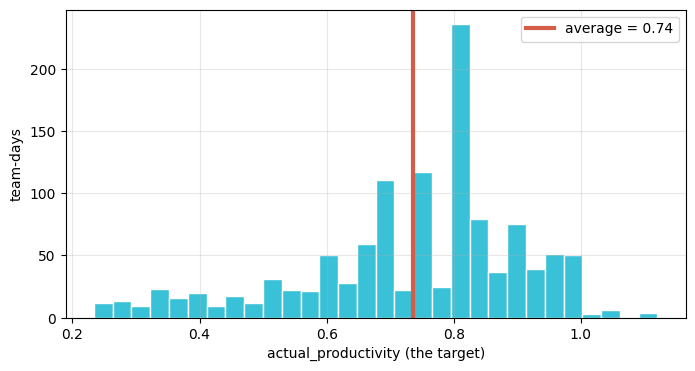

In [4]:
plt.hist(y, bins=30, color=TEAL, edgecolor="white")
plt.axvline(y.mean(), color=CORAL, lw=3, label=f"average = {y.mean():.2f}")
plt.xlabel("actual_productivity (the target)"); plt.ylabel("team-days"); plt.legend(); plt.show()

### The baseline: the dumbest possible model
Always predict the average. Every real model must beat this (one AutoCode test checks exactly that).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
baseline = np.full_like(y_test, y_train.mean())
base_mse = mean_squared_error(y_test, baseline)
print(f"Baseline: always predict {y_train.mean():.3f}  ->  test MSE = {base_mse:.4f}")

Baseline: always predict 0.737  ->  test MSE = 0.0291


---
# PART 1 - Linear regression
## 1.1 One feature: the best straight line
$\hat{y} = b_0 + b_1 x$. Here $x$ = `targeted_productivity`.

In [6]:
x1 = df["targeted_productivity"].values
model1 = LinearRegression().fit(x1.reshape(-1, 1), y)
b0, b1 = model1.intercept_, model1.coef_[0]
print(f"actual = {b0:.3f} + {b1:.3f} x target")

for t in [0.5, 0.7, 0.8]:
    print(f"target {t}  ->  predicted productivity {b0 + b1*t:.3f}")

actual = 0.187 + 0.751 x target
target 0.5  ->  predicted productivity 0.563
target 0.7  ->  predicted productivity 0.713
target 0.8  ->  predicted productivity 0.788


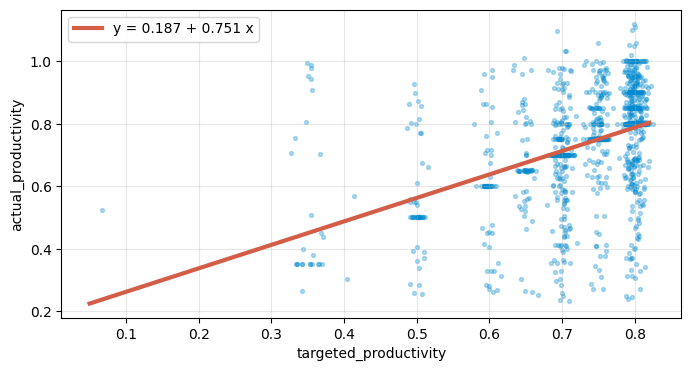

In [7]:
jitter = x1 + np.random.normal(0, 0.008, len(x1))       # small jitter so points don't overlap
plt.scatter(jitter, y, s=8, alpha=0.3, color=BLUE)
xx = np.linspace(0.05, 0.82, 50)
plt.plot(xx, b0 + b1*xx, color=CORAL, lw=3, label=f"y = {b0:.3f} + {b1:.3f} x")
plt.xlabel("targeted_productivity"); plt.ylabel("actual_productivity"); plt.legend(); plt.show()

**Read it:** raising the target by 0.1 raises real productivity by about 0.075. Teams achieve roughly 3/4 of any extra target.

## 1.2 Residuals and MSE by hand
Residual = real - predicted. MSE = average of the squared residuals.

In [8]:
real  = np.array([0.80, 0.70, 0.60])
model_A = np.array([0.75, 0.70, 0.70])
model_B = np.array([0.78, 0.72, 0.62])

for name, pred in [("A", model_A), ("B", model_B)]:
    errors = real - pred
    print(f"Model {name}: errors {errors.round(2)}  squared {(errors**2).round(4)}  MSE = {np.mean(errors**2):.4f}")
print("-> B wins: squaring makes A's one big miss (0.10) very expensive")

Model A: errors [ 0.05  0.   -0.1 ]  squared [0.0025 0.     0.01  ]  MSE = 0.0042
Model B: errors [ 0.02 -0.02 -0.02]  squared [0.0004 0.0004 0.0004]  MSE = 0.0004
-> B wins: squaring makes A's one big miss (0.10) very expensive


## 1.3 Many features + the OLS formula
Multiple regression: $\hat{y} = Xw$. OLS solves it exactly: $w = (X^TX)^{-1}X^Ty$ (Topic 6).
We **standardise** first so the weights are comparable (Topic 5).

In [9]:
scaler = StandardScaler().fit(X_train)
Xs_train, Xs_test = scaler.transform(X_train), scaler.transform(X_test)

# add a column of 1s for the intercept b0
A_train = np.c_[np.ones(len(Xs_train)), Xs_train]
A_test  = np.c_[np.ones(len(Xs_test)),  Xs_test]

w_ols = np.linalg.inv(A_train.T @ A_train) @ A_train.T @ y_train      # the OLS formula
ols_mse = mean_squared_error(y_test, A_test @ w_ols)
print(f"OLS by formula: test MSE = {ols_mse:.4f}   (baseline {base_mse:.4f})")

sk = LinearRegression().fit(Xs_train, y_train)
print("same as sklearn?", np.allclose(w_ols[1:], sk.coef_), "| intercept", round(w_ols[0], 3))

OLS by formula: test MSE = 0.0217   (baseline 0.0291)
same as sklearn? True | intercept 0.737


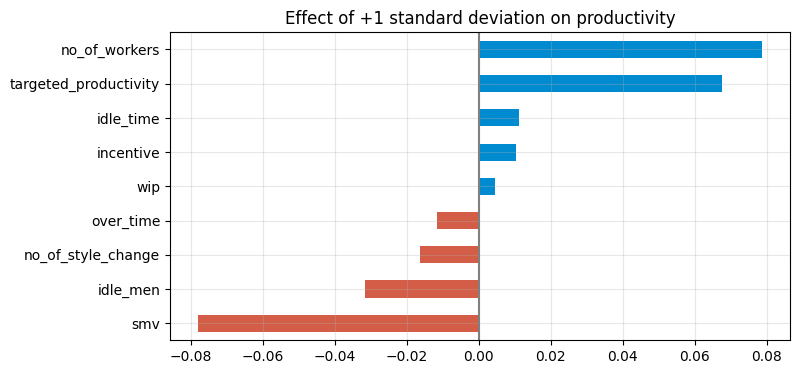

smv                     -0.078
idle_men                -0.031
no_of_style_change      -0.016
over_time               -0.012
wip                      0.005
incentive                0.010
idle_time                0.011
targeted_productivity    0.068
no_of_workers            0.079
dtype: float64

In [10]:
coef = pd.Series(w_ols[1:], index=features).sort_values()
coef.plot.barh(color=[CORAL if v < 0 else BLUE for v in coef])
plt.axvline(0, color="gray"); plt.title("Effect of +1 standard deviation on productivity"); plt.show()
coef.round(3)

Blue raises productivity, coral lowers it. Notice **smv** and **no_of_workers**: almost equal and opposite. We come back to them in 1.6.

## 1.4 Gradient descent from scratch (how the AutoCode base class trains)
Instead of the matrix inverse, repeat: $w \leftarrow w - lr \cdot \nabla MSE$, with
$\nabla MSE = \frac{2}{n} X^T(Xw - y)$.

Gradient descent test MSE = 0.0217
close to OLS weights? True


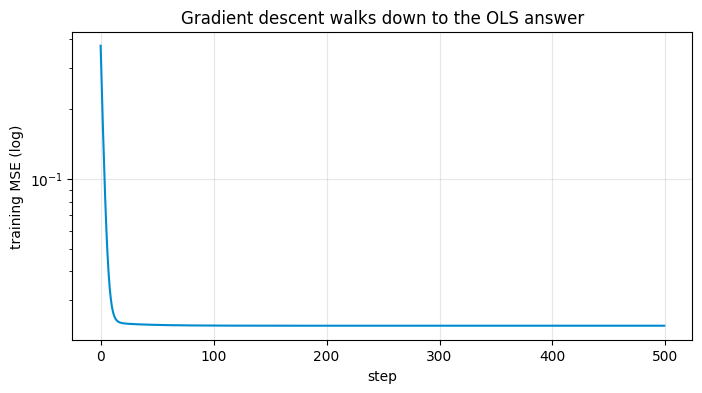

In [11]:
def mse_gradient(X, y, w):
    return 2 / len(y) * X.T @ (X @ w - y)

def gradient_descent(X, y, grad_fn, lr=0.1, steps=500):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(steps):
        w = w - lr * grad_fn(X, y, w)                     # the update rule (Topic 7)
        history.append(np.mean((X @ w - y) ** 2))
    return w, history

w_gd, hist = gradient_descent(A_train, y_train, mse_gradient)
print(f"Gradient descent test MSE = {mean_squared_error(y_test, A_test @ w_gd):.4f}")
print("close to OLS weights?", np.allclose(w_gd, w_ols, atol=1e-3))
plt.plot(hist, color=BLUE); plt.yscale("log"); plt.xlabel("step"); plt.ylabel("training MSE (log)")
plt.title("Gradient descent walks down to the OLS answer"); plt.show()

**TRY IT:** change `lr` to 0.01, 0.3 and 0.6. Too small = slow, too big = it explodes (Topic 7).

In [12]:
lr = 0.3          # <- try 0.01, 0.3, 0.6
w_try, h = gradient_descent(A_train, y_train, mse_gradient, lr=lr, steps=100)
print(f"lr = {lr}: final training MSE = {h[-1]:.4f}" if np.isfinite(h[-1]) else f"lr = {lr}: EXPLODED")

lr = 0.3: final training MSE = 0.0233


## 1.5 Non-linear: polynomial regression and overfitting
Add squared and interaction columns ($x^2$, $x_1x_2$...). The model can bend - and overfit.

In [13]:
results = []
for degree in [1, 2, 3, 4]:
    poly = make_pipeline(StandardScaler(), PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    poly.fit(X_train, y_train)
    n_cols = poly.named_steps["polynomialfeatures"].n_output_features_
    results.append([degree, n_cols, mean_squared_error(y_train, poly.predict(X_train)),
                    mean_squared_error(y_test, poly.predict(X_test))])
pd.DataFrame(results, columns=["degree", "columns", "train MSE", "test MSE"]).round(4)

,degree,columns,train MSE,test MSE
0,1,10,0.0233,0.0217
1,2,55,0.0175,0.0322
2,3,220,0.0146,0.8809
3,4,715,0.0124,10722.0455


**Training error always falls, test error explodes.** Degree 4 has 715 columns and memorises the noise: a textbook **overfit**. Degree 1 (plain linear) is best here.

## 1.6 Multicollinearity: twin features
`smv` and `no_of_workers` are highly correlated.

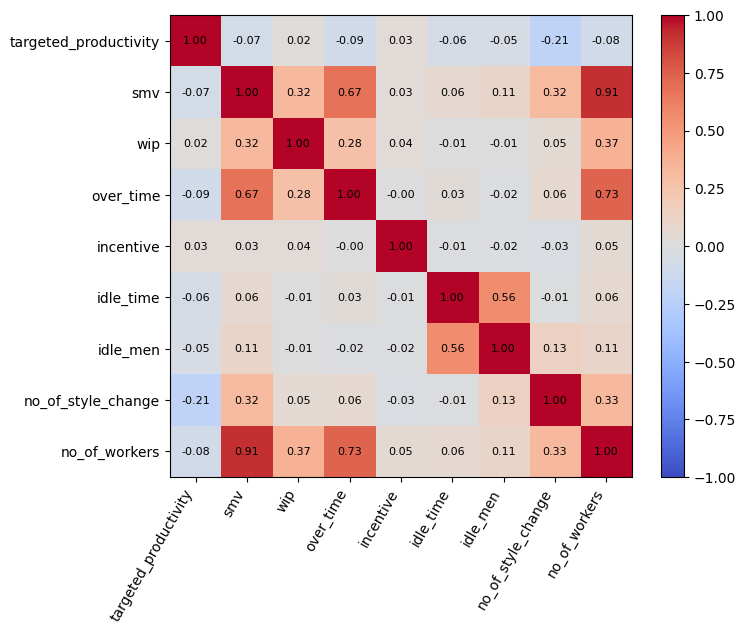

smv vs workers correlation: 0.91


In [14]:
corr = df[features].corr()
plt.figure(figsize=(7.5, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(9), features, rotation=60, ha="right"); plt.yticks(range(9), features)
for i in range(9):
    for j in range(9):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(); plt.grid(False); plt.show()
print("smv vs workers correlation:", round(df["smv"].corr(df["no_of_workers"]), 2))

**Why is it a problem?** The weights become unstable. Refit on 30 random samples of 300 rows and watch the two twin weights jump around - `no_of_workers` even changes sign!

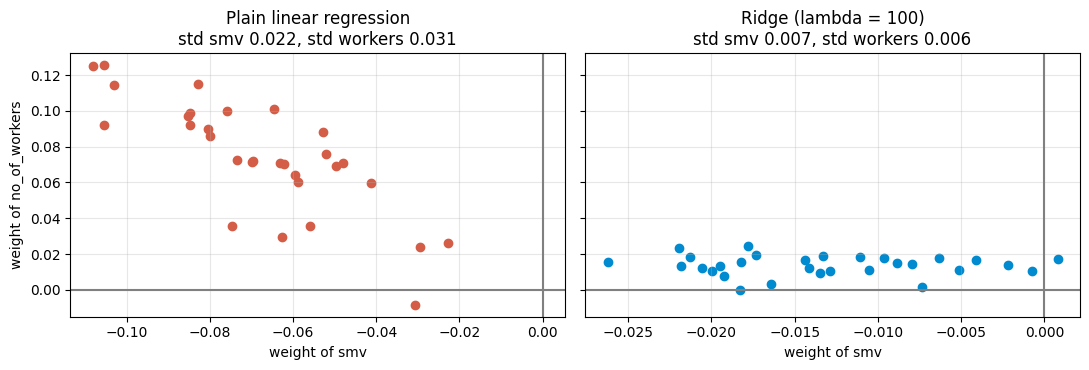

Plain: workers weight ranges from -0.008 to 0.126


In [15]:
Zs = StandardScaler().fit_transform(X)
rng = np.random.default_rng(0)
ols_w, ridge_w = [], []
for _ in range(30):
    idx = rng.integers(0, len(y), 300)
    ols_w.append(LinearRegression().fit(Zs[idx], y[idx]).coef_[[1, 8]])
    ridge_w.append(Ridge(alpha=100).fit(Zs[idx], y[idx]).coef_[[1, 8]])
ols_w, ridge_w = np.array(ols_w), np.array(ridge_w)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for a, W, name in [(ax[0], ols_w, "Plain linear regression"), (ax[1], ridge_w, "Ridge (lambda = 100)")]:
    a.scatter(W[:, 0], W[:, 1], color=CORAL if "Plain" in name else BLUE)
    a.axhline(0, color="gray"); a.axvline(0, color="gray")
    a.set_title(f"{name}\nstd smv {W[:,0].std():.3f}, std workers {W[:,1].std():.3f}")
    a.set_xlabel("weight of smv")
ax[0].set_ylabel("weight of no_of_workers"); plt.tight_layout(); plt.show()
print(f"Plain: workers weight ranges from {ols_w[:,1].min():.3f} to {ols_w[:,1].max():.3f}")

Left: wild, unreliable weights. Right: Ridge keeps them calm. That's Part 2.

---
# PART 2 - Regularization
**Loss = MSE + lambda x penalty.**
- **Ridge (L2):** penalty $\lambda\sum w^2$  ->  gradient gets $+2\lambda w$
- **Lasso (L1):** penalty $\lambda\sum |w|$  ->  gradient gets $+\lambda\,\mathrm{sign}(w)$
- The intercept $b_0$ is **not** penalised.
## 2.1 Ridge and Lasso from scratch (one extra line each)

In [16]:
def ridge_gradient(X, y, w, lam=1.0):
    g = mse_gradient(X, y, w)
    penalty = 2 * lam * w
    penalty[0] = 0                      # do not penalise the intercept (first column of 1s)
    return g + penalty

def lasso_gradient(X, y, w, lam=0.01):
    g = mse_gradient(X, y, w)
    penalty = lam * np.sign(w)          # sign(w) = -1, 0 or +1  (a 'subgradient')
    penalty[0] = 0
    return g + penalty

for name, grad in [("Plain", mse_gradient),
                   ("Ridge lam=0.5", lambda X, y, w: ridge_gradient(X, y, w, 0.5)),
                   ("Lasso lam=0.02", lambda X, y, w: lasso_gradient(X, y, w, 0.02))]:
    w, _ = gradient_descent(A_train, y_train, grad, lr=0.05, steps=3000)
    print(f"{name:<15} test MSE {mean_squared_error(y_test, A_test @ w):.4f}   smv {w[2]:+.3f}   workers {w[9]:+.3f}")

Plain           test MSE 0.0217   smv -0.078   workers +0.079
Ridge lam=0.5   test MSE 0.0227   smv -0.015   workers +0.007
Lasso lam=0.02  test MSE 0.0223   smv -0.007   workers +0.000


Ridge pulls the twins towards each other; Lasso pushes the weaker one towards zero.
(Our scratch Lasso lands **near** zero; sklearn's solver lands **exactly** on zero.)

## 2.2 Coefficient paths with sklearn

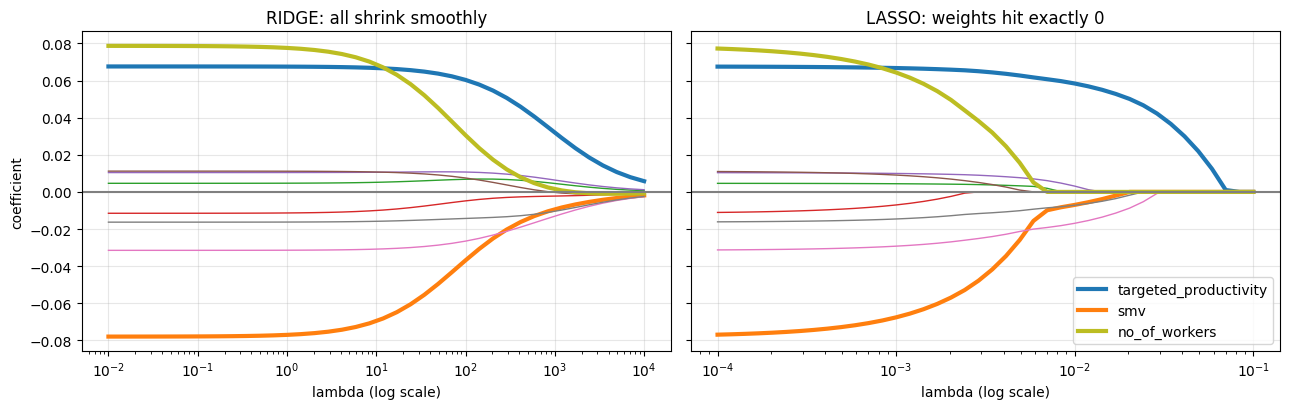

In [17]:
lams_r = np.logspace(-2, 4, 40)
lams_l = np.logspace(-4, -1, 40)
path_r = np.array([Ridge(alpha=a).fit(Xs_train, y_train).coef_ for a in lams_r])
path_l = np.array([Lasso(alpha=a, max_iter=100000).fit(Xs_train, y_train).coef_ for a in lams_l])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for a, lams, P, t in [(ax[0], lams_r, path_r, "RIDGE: all shrink smoothly"), (ax[1], lams_l, path_l, "LASSO: weights hit exactly 0")]:
    for k, f in enumerate(features):
        lw = 3 if f in ["smv", "no_of_workers", "targeted_productivity"] else 1
        a.plot(lams, P[:, k], lw=lw, label=f if lw == 3 else None)
    a.set_xscale("log"); a.axhline(0, color="gray"); a.set_title(t); a.set_xlabel("lambda (log scale)")
ax[0].set_ylabel("coefficient"); ax[1].legend(); plt.tight_layout(); plt.show()

In [18]:
for a in [0.001, 0.01, 0.03]:
    las = Lasso(alpha=a, max_iter=100000).fit(Xs_train, y_train)
    kept = [f for f, c in zip(features, las.coef_) if c != 0]
    print(f"Lasso lambda={a:<6} keeps {len(kept)} features, test MSE {mean_squared_error(y_test, las.predict(Xs_test)):.4f}: {kept}")

Lasso lambda=0.001  keeps 9 features, test MSE 0.0216: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']
Lasso lambda=0.01   keeps 5 features, test MSE 0.0222: ['targeted_productivity', 'smv', 'incentive', 'idle_men', 'no_of_style_change']
Lasso lambda=0.03   keeps 1 features, test MSE 0.0244: ['targeted_productivity']


Lasso = **automatic feature selection**. At lambda = 0.03 only `targeted_productivity` survives: the single most useful feature.

## 2.3 Choosing lambda with cross-validation

In [19]:
cv = KFold(5, shuffle=True, random_state=0)
ridge_cv = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 30), cv=cv)).fit(X_train, y_train)
lasso_cv = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, -1, 30), cv=cv, max_iter=100000)).fit(X_train, y_train)
print(f"best Ridge lambda = {ridge_cv[-1].alpha_:.3f}   test MSE {mean_squared_error(y_test, ridge_cv.predict(X_test)):.4f}")
print(f"best Lasso lambda = {lasso_cv[-1].alpha_:.5f} test MSE {mean_squared_error(y_test, lasso_cv.predict(X_test)):.4f}")
print(f"plain linear       test MSE {ols_mse:.4f}")

best Ridge lambda = 0.788   test MSE 0.0217
best Lasso lambda = 0.00010 test MSE 0.0217
plain linear       test MSE 0.0217


Honest result: with only 9 features and 1,197 rows the model barely overfits, so regularization mainly adds **stability**, not accuracy. With thousands of features it becomes essential.

## 2.4 Why we MUST scale before regularizing

In [20]:
raw = Ridge(alpha=1.0).fit(X_train, y_train).coef_
scaled = Ridge(alpha=1.0).fit(Xs_train, y_train).coef_
pd.DataFrame({"raw features": raw, "standardised": scaled}, index=features).round(5)

,raw features,standardised
targeted_productivity,0.60654,0.06748
smv,-0.00704,-0.07699
wip,0.00000,0.00470
over_time,-0.00000,-0.01134
incentive,0.00007,0.01043
idle_time,0.00104,0.01114
idle_men,-0.00953,-0.03140
no_of_style_change,-0.04048,-0.01623
no_of_workers,0.00354,0.07755


Raw weights reflect **units**, not importance: `over_time` is in minutes (up to 25,920) so its weight is tiny and escapes the penalty, while `targeted_productivity` (0 to 0.8) gets a big weight and is punished. Standardise first so the penalty is fair.

---
# PART 3 - Logistic regression (classification)
New question: **is this team-day HIGH productivity (actual >= 0.75)?**  1 = yes, 0 = no.

In [21]:
y_cls = (y >= 0.75).astype(int)
print("share of HIGH days:", y_cls.mean().round(2), " -> baseline accuracy (always 'high'):", y_cls.mean().round(2))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y_cls, test_size=0.3, random_state=0, stratify=y_cls)
sc_c = StandardScaler().fit(Xc_train)
Ac_train = np.c_[np.ones(len(Xc_train)), sc_c.transform(Xc_train)]
Ac_test  = np.c_[np.ones(len(Xc_test)),  sc_c.transform(Xc_test)]

share of HIGH days: 0.6  -> baseline accuracy (always 'high'): 0.6


## 3.1 The sigmoid: squash any number into 0...1

z = -2  ->  sigmoid = 0.12
z = -1  ->  sigmoid = 0.27
z = +0  ->  sigmoid = 0.50
z = +1  ->  sigmoid = 0.73
z = +2  ->  sigmoid = 0.88


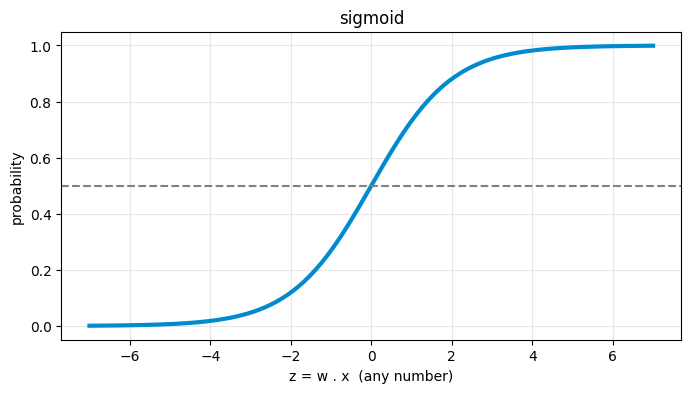

In [22]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-2, -1, 0, 1, 2]:
    print(f"z = {z:+d}  ->  sigmoid = {sigmoid(z):.2f}")
z = np.linspace(-7, 7, 200)
plt.plot(z, sigmoid(z), color=BLUE, lw=3); plt.axhline(0.5, color="gray", ls="--")
plt.xlabel("z = w . x  (any number)"); plt.ylabel("probability"); plt.title("sigmoid"); plt.show()

## 3.2 One feature: does a bonus help?

P(high) = sigmoid(-0.23 + 0.027 x bonus)
bonus   0: P(high) = 44%
bonus  25: P(high) = 61%
bonus  50: P(high) = 75%
bonus 100: P(high) = 92%


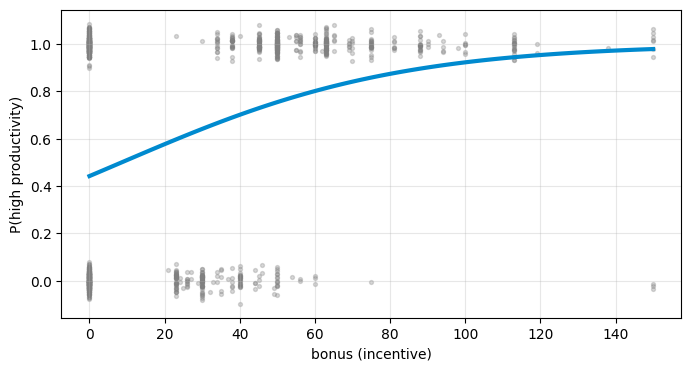

In [23]:
bonus = df["incentive"].clip(upper=150).values.reshape(-1, 1)
lg1 = LogisticRegression().fit(bonus, y_cls)
print(f"P(high) = sigmoid({lg1.intercept_[0]:.2f} + {lg1.coef_[0][0]:.3f} x bonus)")
for b in [0, 25, 50, 100]:
    print(f"bonus {b:>3}: P(high) = {lg1.predict_proba([[b]])[0, 1]:.0%}")
g = np.linspace(0, 150, 100).reshape(-1, 1)
plt.scatter(bonus, y_cls + np.random.normal(0, 0.03, len(y_cls)), s=8, alpha=0.3, color="gray")
plt.plot(g, lg1.predict_proba(g)[:, 1], color=BLUE, lw=3)
plt.xlabel("bonus (incentive)"); plt.ylabel("P(high productivity)"); plt.show()

## 3.3 Log-loss and gradient descent from scratch
Log-loss: $-\frac{1}{n}\sum[y\log p + (1-y)\log(1-p)]$. Its gradient has the **same shape as linear regression**: $\frac{1}{n}X^T(\sigma(Xw) - y)$.

our logistic regression: accuracy 0.717   (baseline 0.597)
sklearn:                 accuracy 0.717


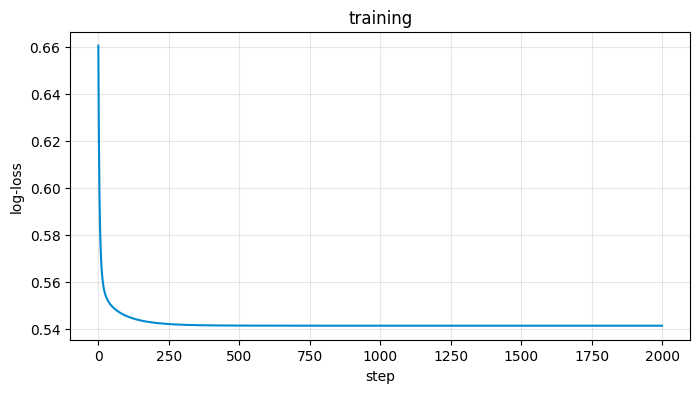

In [24]:
def log_loss(X, y, w):
    p = np.clip(sigmoid(X @ w), 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def logistic_gradient(X, y, w):
    return X.T @ (sigmoid(X @ w) - y) / len(y)

w = np.zeros(Ac_train.shape[1]); losses = []
for _ in range(2000):
    w = w - 0.5 * logistic_gradient(Ac_train, yc_train, w)
    losses.append(log_loss(Ac_train, yc_train, w))

p_test = sigmoid(Ac_test @ w)
print(f"our logistic regression: accuracy {accuracy_score(yc_test, p_test >= 0.5):.3f}   (baseline {max(yc_test.mean(), 1 - yc_test.mean()):.3f})")
sk_lg = LogisticRegression(max_iter=3000).fit(sc_c.transform(Xc_train), yc_train)
print(f"sklearn:                 accuracy {sk_lg.score(sc_c.transform(Xc_test), yc_test):.3f}")
plt.plot(losses, color=BLUE); plt.xlabel("step"); plt.ylabel("log-loss"); plt.title("training"); plt.show()

In [25]:
for p, y_true in [(0.9, 1), (0.6, 1), (0.1, 1)]:
    print(f"true class {y_true}, model says p = {p}:  loss = {-np.log(p):.2f}")
print("-> confident AND wrong is punished hardest")

true class 1, model says p = 0.9:  loss = 0.11
true class 1, model says p = 0.6:  loss = 0.51
true class 1, model says p = 0.1:  loss = 2.30
-> confident AND wrong is punished hardest


## 3.4 The threshold is a choice
**TRY IT:** change the threshold and see the trade-off between missed HIGH days and false alarms.

In [26]:
threshold = 0.5      # <- try 0.3, 0.5, 0.7
pred = (p_test >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(yc_test, pred).ravel()
print(f"threshold {threshold}:  accuracy {accuracy_score(yc_test, pred):.3f}")
print(f"  correctly found HIGH: {tp}   missed HIGH: {fn}   false alarms: {fp}   correctly NOT high: {tn}")

threshold 0.5:  accuracy 0.717
  correctly found HIGH: 195   missed HIGH: 20   false alarms: 82   correctly NOT high: 63


In [27]:
rows = []
for t in np.arange(0.2, 0.85, 0.1):
    tn, fp, fn, tp = confusion_matrix(yc_test, (p_test >= t).astype(int)).ravel()
    rows.append([round(t, 1), accuracy_score(yc_test, p_test >= t), fn, fp])
pd.DataFrame(rows, columns=["threshold", "accuracy", "missed HIGH", "false alarms"]).round(3)

,threshold,accuracy,missed HIGH,false alarms
0,0.2,0.631,3,130
1,0.3,0.650,6,120
2,0.4,0.661,15,107
3,0.5,0.717,20,82
4,0.6,0.739,35,59
5,0.7,0.736,65,30
6,0.8,0.614,136,3


Low threshold = few misses, many false alarms (fraud, disease screening). High threshold = cautious (spam filter).

## 3.5 Reading weights as odds
$e^{w}$ = how the **odds** of HIGH change for +1 standard deviation of a feature.

In [28]:
odds = pd.Series(np.exp(w[1:]), index=features).sort_values()
print(odds.round(2))
print("\n> 1 raises the odds of a HIGH day, < 1 lowers them")

smv                      0.41
no_of_style_change       0.63
idle_men                 0.67
idle_time                0.71
over_time                0.78
wip                      1.08
incentive                1.87
targeted_productivity    2.70
no_of_workers            3.23
dtype: float64

> 1 raises the odds of a HIGH day, < 1 lowers them


---
# Summary: the four AutoCode models in one place
Training is done by the base class with gradient descent - you write the **gradient** and the **prediction**.

| Model | Prediction | Gradient |
|---|---|---|
| Linear | $Xw$ | $\frac{2}{n}X^T(Xw-y)$ |
| Ridge | $Xw$ | linear $+ 2\lambda w$ |
| Lasso | $Xw$ | linear $+ \lambda\,\mathrm{sign}(w)$ |
| Logistic | $\sigma(Xw) \ge 0.5$ | $\frac{1}{n}X^T(\sigma(Xw)-y)$ |

(The AutoCode base class may use slightly different names or scaling such as 1/(2n) - follow its conventions.)

In [29]:
final = pd.DataFrame({
    "model": ["baseline (average)", "linear (OLS)", "linear (gradient descent)", "Ridge (CV)", "Lasso (CV)"],
    "test MSE": [base_mse, ols_mse, mean_squared_error(y_test, A_test @ w_gd),
                 mean_squared_error(y_test, ridge_cv.predict(X_test)), mean_squared_error(y_test, lasso_cv.predict(X_test))]})
final["better than baseline"] = (1 - final["test MSE"] / base_mse).map("{:.0%}".format)
final.round(4)

,model,test MSE,better than baseline
0,baseline (average),0.0291,0%
1,linear (OLS),0.0217,25%
2,linear (gradient descent),0.0217,25%
3,Ridge (CV),0.0217,25%
4,Lasso (CV),0.0217,26%
